<div style="background-color:#EAEAEA;padding:20px;border-left:5px solid #6C757D;border-radius:6px;">
<table style="width:100%; border:none;"><tr style="border:none;">
<td style="border:none; vertical-align:top;">
<h1 style="font-size:32px; margin-top:0;">Master's Thesis</h1>
<hr style="margin:16px 0 22px 0;">
<p style="font-size:22px; line-height:1.5; margin:0;"><strong>Master's Degree in Advanced Physics</strong> - <strong>Universitat de Valencia</strong></p>
<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:</p>
<div style="font-size:25px;font-weight:700;line-height:1.3;margin-top:14px;margin-bottom:26px;">Fast Simulation of Neutrino Oscillations in Matter</div>
<p style="font-size:14px; line-height:1.55;"><strong>Author</strong><br>Juan Ramon Diaz Santos - <a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a></p>
<p style="font-size:14px; line-height:1.55;"><strong>Supervisors</strong><br>Roberto Ruiz de Austri Bazan - <a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>Michele Lucente - <a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a></p>
<p style="font-size:14px; line-height:1.55; margin-bottom:0;"><strong>Date</strong><br>September 2026</p></td>
<td style="border:none;width:230px;padding-left:25px;text-align:right;vertical-align:top;"><img src="../../../logo_uv.png" alt="Universitat de Valencia" style="width:200px; margin-top:5px;"></td>
</tr></table></div>

# Daya Bay -- Official Data Release Fetch
---
Downloads the official Daya Bay Collaboration "Full Data Release" analysis dataset (TSV package) and converts it into the tidy `.csv` format `tpeanuts.detector.dayabay` consumes. This is a real 6-reactor / 8-detector precision measurement, not an illustrative placeholder.

Source: [Daya Bay Collaboration, "Full Data Release of the Daya Bay Reactor Neutrino Experiment", Zenodo, DOI:10.5281/zenodo.17587229](https://doi.org/10.5281/zenodo.17587229), supplementary to [F. P. An et al., Phys. Rev. Lett. 130, 161802 (2023)](https://doi.org/10.1103/PhysRevLett.130.161802). `zenodo.org` itself returns 403 (Cloudflare) from this environment, so this notebook fetches from the official GitHub mirror of the analysis dataset instead: [github.com/dayabay-experiment/dayabay-data-official](https://github.com/dayabay-experiment/dayabay-data-official).

**Scope of this fetch**: baselines, real Huber-Mueller antineutrino spectra (4 isotopes), reactor parameters (fission fractions, energy/fission, thermal power), real IBD prompt-energy spectra and backgrounds for the **8AD data-taking period only** (all 8 detectors online), real target proton counts and exposure, real energy-resolution parameters, the real analysis binning, Daya Bay's own published best-fit oscillation parameters (for comparison), the real IBD cross-section constants, the real IAV response matrix and LSNL nonlinearity curve, the real non-equilibrium and spent-nuclear-fuel (SNF) flux corrections, and the real weekly-resolved per-reactor antineutrino rate history. Not fetched: the 6AD/7AD periods and the LSNL/background systematic pull curves -- see `tpeanuts.detector.dayabay`'s module docstring for why.

## Table of Contents

| # | Section |
|---|---|
| [0](#0.-Theoretical-Framework) | **Theoretical Framework** |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** |
| [3](#3.-Baselines) | **Baselines** |
| [4](#4.-Reactor-Parameters) | **Reactor Parameters** |
| [5](#5.-Huber-Mueller-Antineutrino-Spectra) | **Huber-Mueller Antineutrino Spectra** |
| [6](#6.-Target-Protons-and-Energy-Resolution) | **Target Protons and Energy Resolution** |
| [7](#7.-Real-IBD-Spectra-8AD) | **Real IBD Spectra (8AD)** |
| [8](#8.-Real-Backgrounds-8AD) | **Real Backgrounds (8AD)** |
| [9](#9.-Real-Exposure-8AD) | **Real Exposure (8AD)** |
| [10](#10.-Analysis-Binning-and-Published-Truth) | **Analysis Binning and Published Truth** |
| [12](#12.-Real-IBD-Cross-Section-Constants) | **Real IBD Cross-Section Constants** |
| [13](#13.-Real-Detector-Response-IAV-Matrix-and-LSNL-Curve) | **Real Detector Response: IAV Matrix and LSNL Curve** |
| [14](#14.-Real-Reactor-Flux-Corrections-Non-Equilibrium-and-SNF) | **Real Reactor Flux Corrections: Non-Equilibrium and SNF** |
| [15](#15.-Real-Weekly-Reactor-Antineutrino-Rate) | **Real Weekly Reactor Antineutrino Rate** |
| [16](#16.-Real-Global-Normalization-Nominal) | **Real Global Normalization (Nominal)** |
| [18](#18.-Real-LSNL-Pull-Curves-Systematic-Variations) | **Real LSNL Pull Curves (Systematic Variations)** |
| [19](#19.-Summary) | **Summary** |


## 0. Theoretical Framework
---
Every file below is fetched from `raw.githubusercontent.com/dayabay-experiment/dayabay-data-official/main/src/dayabay_data_official/data/tsv/...` and written to `data/detector/dayabay/`. YAML parameter files are parsed with PyYAML; `.tsv.bz2` files are decompressed with the standard-library `bz2` module and parsed with pandas.

**References**

- [1] Daya Bay Collaboration (2025). Full Data Release of the Daya Bay Reactor Neutrino Experiment. v1.0.0, Zenodo, https://doi.org/10.5281/zenodo.17587229.
- [2] An, F. P. et al. (2023). Precision Measurement of Reactor Antineutrino Oscillation at Kilometer-Scale Baselines by Daya Bay. *Phys. Rev. Lett.* 130, 161802.

The analysis treats provenance, dimensional conventions, bin measures, interpolation, and normalization as part of the physical definition of the external product; transformations are accepted only when these invariants are preserved.


## 1. Libraries

This stage evaluates libraries with explicit provenance, dimensional conventions, numerical controls, and reproducibility checks.


In [1]:
from __future__ import annotations

import bz2
import io
import time
import urllib.request

import numpy as np
import pandas as pd
import yaml

from tpeanuts.notebooks.notebookConfig import load_notebook_config

config = load_notebook_config()
DATA_DIR = config.data_dir / "detector" / "dayabay"
DATA_DIR.mkdir(parents=True, exist_ok=True)
(DATA_DIR / "ibd_spectra").mkdir(exist_ok=True)
(DATA_DIR / "background_shapes").mkdir(exist_ok=True)

BASE_URL = "https://raw.githubusercontent.com/dayabay-experiment/dayabay-data-official/main/src/dayabay_data_official/data/tsv"
_HEADERS = {"User-Agent": "Mozilla/5.0 (tpeanuts thesis data-fetch script)"}

DETECTORS_8AD = ["AD11", "AD12", "AD21", "AD22", "AD31", "AD32", "AD33", "AD34"]
BG_CATEGORIES = ["accidentals", "alpha_neutron", "amc", "fast_neutrons", "lithium_helium"]
ISOTOPES = ["U235", "U238", "Pu239", "Pu241"]










print(f"Data dir: {DATA_DIR}")
import matplotlib.pyplot as plt


Data dir: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\detector\dayabay


## 2. Paths and Configuration

This stage evaluates paths and configuration with explicit provenance, dimensional conventions, numerical controls, and reproducibility checks.


### 2.1 Paths

Repository-relative paths identify primary-source files, metadata, generated products, and output locations.


### 2.2 Configuration

Acquisition controls, physical units, grids, interpolation rules, validation tolerances, and storage formats are fixed here before data processing.


### 2.3 Local Helpers

Notebook-local functions implement repeated acquisition, parsing, transformation, storage, and validation operations after paths and conventions are fixed.


In [ ]:
def fetch_bytes(path: str, *, retries: int = 5, timeout: float = 30.0) -> bytes:
    '''GET BASE_URL/path as raw bytes, retrying transient failures.'''
    url = f"{BASE_URL}/{path}"
    last_error = None
    for attempt in range(retries):
        try:
            req = urllib.request.Request(url, headers=_HEADERS)
            with urllib.request.urlopen(req, timeout=timeout) as resp:
                return resp.read()
        except Exception as exc:  # noqa: BLE001 -- retry any transient network error
            last_error = exc
            time.sleep(1.5 * (attempt + 1))
    raise RuntimeError(f"failed to fetch {url} after {retries} attempts") from last_error

def fetch_text(path: str) -> str:
    return fetch_bytes(path).decode("utf-8")

def fetch_yaml(path: str) -> dict:
    return yaml.safe_load(fetch_text(path))

def fetch_tsv_bz2(path: str) -> pd.DataFrame:
    raw = bz2.decompress(fetch_bytes(path)).decode("utf-8")
    return pd.read_csv(io.StringIO(raw), sep="\t")


## 3. Baselines

`parameters/baselines.yaml`: distance in meters between each of the 6 reactor cores (R1-R6) and each of the 8 antineutrino detectors, flattened here into a tidy (detector, reactor, baseline_km) table.

**Expected results:**<br>
- The baselines products are finite, dimensionally consistent, and reproducible from the cited primary source.
- Parsing, interpolation, normalization, and serialization preserve the published binning and physical measure.
- Validation diagnostics remain within the stated numerical and provenance tolerances.


In [2]:
baselines_yaml = fetch_yaml("parameters/baselines.yaml")
rows = []
for detector, per_reactor in baselines_yaml["parameters"]["baseline"].items():
    for reactor, baseline_m in per_reactor.items():
        rows.append({"detector": detector, "reactor": reactor, "baseline_km": baseline_m / 1000.0})
baselines_df = pd.DataFrame(rows).sort_values(["detector", "reactor"]).reset_index(drop=True)

assert len(baselines_df) == 48, f"expected 6 reactors x 8 detectors = 48 rows, got {len(baselines_df)}"

out = DATA_DIR / "baselines.csv"
baselines_df.to_csv(out, index=False)
print(f"wrote {out}  shape={baselines_df.shape}")
display(baselines_df.pivot(index="detector", columns="reactor", values="baseline_km"))


wrote G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\detector\dayabay\baselines.csv  shape=(48, 3)


reactor,R1,R2,R3,R4,R5,R6
detector,,,,,,
AD11,0.36238,0.37176,0.90347,0.81716,1.35362,1.26532
AD12,0.35794,0.36841,0.90335,0.81690,1.35423,1.26589
AD21,1.33248,1.35815,0.46757,0.48958,0.55758,0.49921
AD22,1.33743,1.36288,0.47297,0.49535,0.55871,0.50107
AD31,1.91963,1.89434,1.53318,1.53363,1.55138,1.52494
AD32,1.91752,1.89198,1.53492,1.53503,1.55477,1.52805
AD33,1.92526,1.89986,1.53893,1.53947,1.55634,1.53008
AD34,1.92315,1.89751,1.54067,1.54087,1.55972,1.53318


## 4. Reactor Parameters

Real time-averaged fission fractions, energy released per fission (per isotope), and nominal thermal power (shared by all 6 cores) -- `parameters/reactor_fission_fractions.yaml`, `parameters/reactor_energy_per_fission.yaml`, `parameters/reactor_thermal_power_nominal.yaml`.

**Expected results:**<br>
- The reactor parameters products are finite, dimensionally consistent, and reproducible from the cited primary source.
- Parsing, interpolation, normalization, and serialization preserve the published binning and physical measure.
- Validation diagnostics remain within the stated numerical and provenance tolerances.


In [3]:
fission_fractions = fetch_yaml("parameters/reactor_fission_fractions.yaml")["parameters"]["fission_fractions"]
energy_per_fission = fetch_yaml("parameters/reactor_energy_per_fission.yaml")["parameters"]["energy_per_fission"]
thermal_power_gw = fetch_yaml("parameters/reactor_thermal_power_nominal.yaml")["parameters"]["nominal_thermal_power"]

reactor_params_df = pd.DataFrame(
    [
        {"isotope": iso, "fission_fraction": fission_fractions[iso], "energy_per_fission_MeV": energy_per_fission[iso][0]}
        for iso in ISOTOPES
    ]
)
total_fraction = reactor_params_df["fission_fraction"].sum()
print(f"sum of fission fractions: {total_fraction:.6f} (should be ~1)")
assert abs(total_fraction - 1.0) < 1.0e-3

out = DATA_DIR / "reactor_parameters.csv"
reactor_params_df.to_csv(out, index=False)
print(f"wrote {out}  shape={reactor_params_df.shape}")
print(f"nominal thermal power per core: {thermal_power_gw} GW")

with open(DATA_DIR / "reactor_thermal_power_gw.txt", "w") as f:
    f.write(str(thermal_power_gw))
display(reactor_params_df)


sum of fission fractions: 1.000001 (should be ~1)
wrote G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\detector\dayabay\reactor_parameters.csv  shape=(4, 3)
nominal thermal power per core: 2.895 GW


,isotope,fission_fraction,energy_per_fission_MeV
0,U235,0.563452,202.36
1,U238,0.075930,205.99
2,Pu239,0.304785,211.12
3,Pu241,0.055834,214.26


## 5. Huber-Mueller Antineutrino Spectra

Real per-isotope antineutrino emission spectra (²³⁵U, ²³⁹Pu, ²⁴¹Pu from Huber, Phys. Rev. C84, 024617 (2011); ²³⁸U from Mueller et al., Phys. Rev. C83, 054615 (2011)), 50 keV mesh, units antineutrinos/fission/MeV -- `reactor_antineutrino_spectra_hm.tsv/*`.

**Expected results:**<br>
- The huber-mueller antineutrino spectra products are finite, dimensionally consistent, and reproducible from the cited primary source.
- Parsing, interpolation, normalization, and serialization preserve the published binning and physical measure.
- Validation diagnostics remain within the stated numerical and provenance tolerances.


wrote G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\detector\dayabay\huber_mueller_spectra.csv  shape=(904, 3)


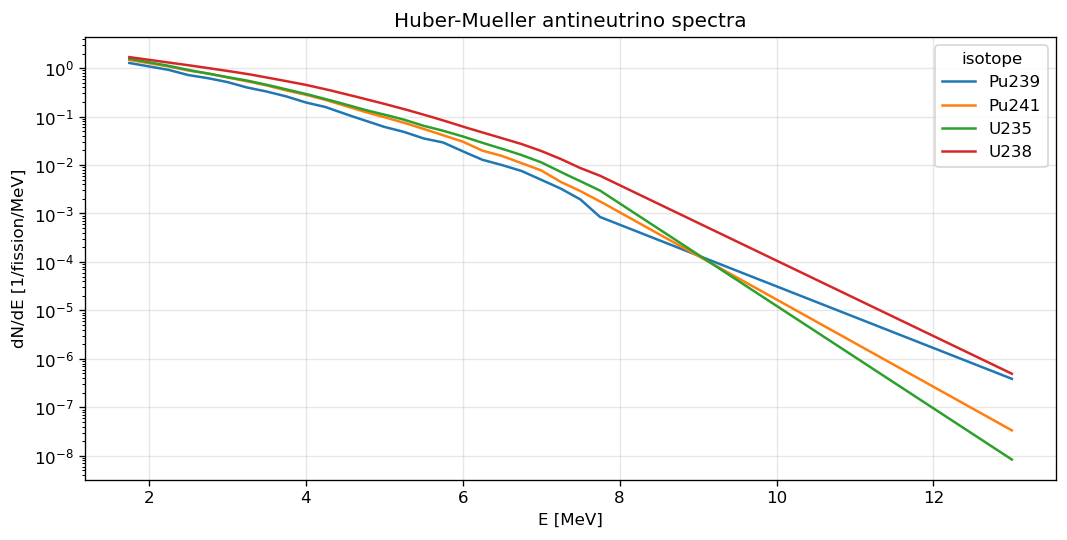

In [4]:
hm_frames = []
for iso in ISOTOPES:
    df = fetch_tsv_bz2(f"reactor_antineutrino_spectra_hm.tsv/reactor_antineutrino_spectra_hm_{iso}.tsv.bz2")
    df = df.rename(columns={"E_MeV": "E_MeV", "N_density": "N_per_fission_per_MeV"})
    df.insert(0, "isotope", iso)
    hm_frames.append(df)

hm_df = pd.concat(hm_frames, ignore_index=True)
assert (hm_df["N_per_fission_per_MeV"] >= 0).all(), "Huber-Mueller spectra must be non-negative"

out = DATA_DIR / "huber_mueller_spectra.csv"
hm_df.to_csv(out, index=False)
print(f"wrote {out}  shape={hm_df.shape}")

fig_df = hm_df.pivot(index="E_MeV", columns="isotope", values="N_per_fission_per_MeV")
ax = fig_df.plot(logy=True, figsize=(9.0, 4.6), title="Huber-Mueller antineutrino spectra")
ax.set_xlabel("E [MeV]"); ax.set_ylabel("dN/dE [1/fission/MeV]")
plt.tight_layout(); plt.show()


## 6. Target Protons and Energy Resolution

Real target free-proton count per detector (`detector_n_protons_nominal.yaml` x `detector_n_protons_correction.yaml`) and the real 3-parameter energy-resolution formula sigma(E)/E = sqrt(a^2 + b^2/E + c^2/E^2) (`detector_eres.yaml`).

**Expected results:**<br>
- The target protons and energy resolution products are finite, dimensionally consistent, and reproducible from the cited primary source.
- Parsing, interpolation, normalization, and serialization preserve the published binning and physical measure.
- Validation diagnostics remain within the stated numerical and provenance tolerances.


In [5]:
n_protons_nominal = fetch_yaml("parameters/detector_n_protons_nominal.yaml")["parameters"]["n_protons_nominal_ad"]
n_protons_correction = fetch_yaml("parameters/detector_n_protons_correction.yaml")["parameters"]["n_protons_correction"]

n_protons_df = pd.DataFrame(
    [
        {"detector": det, "n_protons": n_protons_nominal * n_protons_correction[det]}
        for det in DETECTORS_8AD
    ]
)
out = DATA_DIR / "n_protons.csv"
n_protons_df.to_csv(out, index=False)
print(f"wrote {out}  shape={n_protons_df.shape}")
display(n_protons_df)

eres = fetch_yaml("parameters/detector_eres.yaml")["parameters"]["eres"]
eres_df = pd.DataFrame(
    [{"parameter": name, "value": value[0]} for name, value in eres.items()]
)
out = DATA_DIR / "eres_parameters.csv"
eres_df.to_csv(out, index=False)
print(f"wrote {out}")
display(eres_df)

# Real IBD-selection efficiency (Gd-capture + delayed-coincidence + analysis
# cuts) -- separate from and multiplicative with the daily eff_livetime
# (muon-veto + multiplicity, Section 8): confirmed empirically (not just
# from the README's prose) by comparing an initial forward prediction
# using eff_livetime alone against the real observed spectrum -- both near
# and far halls came out ~25% too high, and 1/1.25 = 0.80 matches this
# value almost exactly, ruling out the alternative reading that it was
# merely a dataset-average restatement of the daily eff column.
detector_efficiency = fetch_yaml("parameters/detector_efficiency.yaml")["parameters"]["efficiency"]
with open(DATA_DIR / "detector_efficiency.txt", "w") as f:
    f.write(str(detector_efficiency))
print(f"detector efficiency (real, separate from eff_livetime): {detector_efficiency}")


wrote G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\detector\dayabay\n_protons.csv  shape=(8, 2)


,detector,n_protons
0,AD11,1.429570e+30
1,AD12,1.431434e+30
2,AD21,1.425986e+30
3,AD22,1.429785e+30
4,AD31,1.427850e+30
5,AD32,1.433011e+30
6,AD33,1.426057e+30
7,AD34,1.428853e+30


wrote G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\detector\dayabay\eres_parameters.csv


,parameter,value
0,a_nonuniform,0.016
1,b_stat,0.081
2,c_noise,0.026


detector efficiency (real, separate from eff_livetime): 0.8025190696388883


## 7. Real IBD Spectra (8AD)

Real observed inverse-beta-decay prompt-energy candidate spectra, 0.05 MeV bins from 0 to 12 MeV, per detector, for the 8AD (all 8 detectors online) data-taking period -- `dayabay_dataset/dayabay_ibd_spectra_8AD.tsv/ibd_spectrum_{AD}.tsv.bz2`.

**Expected results:**<br>
- The real ibd spectra (8ad) products are finite, dimensionally consistent, and reproducible from the cited primary source.
- Parsing, interpolation, normalization, and serialization preserve the published binning and physical measure.
- Validation diagnostics remain within the stated numerical and provenance tolerances.


In [6]:
ibd_totals = {}
for det in DETECTORS_8AD:
    df = fetch_tsv_bz2(f"dayabay_dataset/dayabay_ibd_spectra_8AD.tsv/ibd_spectrum_{det}.tsv.bz2")
    out = DATA_DIR / "ibd_spectra" / f"ibd_spectrum_{det}.csv"
    df.to_csv(out, index=False)
    ibd_totals[det] = int(df["N"].sum())

print("real total IBD candidate counts per detector (8AD period):")
for det, total in ibd_totals.items():
    print(f"  {det}: {total}")


real total IBD candidate counts per detector (8AD period):
  AD11: 695290
  AD12: 704771
  AD21: 667823
  AD22: 658020
  AD31: 97069
  AD32: 97504
  AD33: 96793
  AD34: 97664


## 8. Real Backgrounds (8AD)

Real background rates (events/day, 5 categories) per detector, plus their real normalized shape histograms (same 0.05 MeV binning as Section 6, each integrating to 1) -- `dayabay_background_rates_8AD.tsv.bz2`, `dayabay_background_spectra_8AD.tsv/spectrum_shape_{category}_{AD}.tsv.bz2`.

**Expected results:**<br>
- The real backgrounds (8ad) products are finite, dimensionally consistent, and reproducible from the cited primary source.
- Parsing, interpolation, normalization, and serialization preserve the published binning and physical measure.
- Validation diagnostics remain within the stated numerical and provenance tolerances.


In [7]:
bg_rates_df = fetch_tsv_bz2("dayabay_dataset/dayabay_background_rates.tsv/dayabay_background_rates_8AD.tsv.bz2")
out = DATA_DIR / "background_rates_8AD.csv"
bg_rates_df.to_csv(out, index=False)
print(f"wrote {out}  shape={bg_rates_df.shape}")
display(bg_rates_df)

n_shapes = 0
for det in DETECTORS_8AD:
    for category in BG_CATEGORIES:
        try:
            df = fetch_tsv_bz2(
                f"dayabay_dataset/dayabay_background_spectra_8AD.tsv/spectrum_shape_{category}_{det}.tsv.bz2"
            )
        except RuntimeError:
            print(f"  (no shape file for {category}/{det}, skipping)")
            continue
        out = DATA_DIR / "background_shapes" / f"spectrum_shape_{category}_{det}.csv"
        df.to_csv(out, index=False)
        n_shapes += 1

print(f"wrote {n_shapes} background shape files")


wrote G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\detector\dayabay\background_rates_8AD.csv  shape=(10, 9)


,Label,AD11,AD12,AD21,AD22,AD31,AD32,AD33,AD34
0,accidentals_rate,6.927510,6.856490,5.056920,5.108820,0.748770,0.691436,0.716740,0.766731
1,accidentals_uncertainty,0.008580,0.008486,0.006955,0.007015,0.002450,0.002354,0.002405,0.002491
2,lithium_helium_rate,2.920000,2.920000,2.450000,2.450000,0.260000,0.260000,0.260000,0.260000
3,lithium_helium_uncertainty,0.780000,0.780000,0.570000,0.570000,0.040000,0.040000,0.040000,0.040000
4,fast_neutrons_rate,0.841000,0.841000,0.553000,0.553000,0.044000,0.044000,0.044000,0.044000
5,fast_neutrons_uncertainty,0.168200,0.168200,0.110600,0.110600,0.008800,0.008800,0.008800,0.008800
6,amc_rate,0.142094,0.144694,0.123807,0.132949,0.038222,0.031154,0.033348,0.039551
7,amc_uncertainty,0.060285,0.061388,0.052527,0.056406,0.016216,0.013217,0.014148,0.016780
8,alpha_neutron_rate,0.080000,0.060000,0.040000,0.060000,0.040000,0.040000,0.030000,0.040000
9,alpha_neutron_uncertainty,0.040000,0.030000,0.020000,0.030000,0.020000,0.020000,0.015000,0.020000


wrote 40 background shape files


## 9. Real Exposure (8AD)

Real daily effective livetime (`livetime * eff`) from the data release; the separately published IBD-selection efficiency is retained as its own detector parameter, summed over days where `n_det==8` to get each detector's real 8AD-period exposure -- `dayabay_daily_detector_data_{AD}.tsv.bz2`.

**Expected results:**<br>
- The real exposure (8ad) products are finite, dimensionally consistent, and reproducible from the cited primary source.
- Parsing, interpolation, normalization, and serialization preserve the published binning and physical measure.
- Validation diagnostics remain within the stated numerical and provenance tolerances.


In [8]:
exposure_rows = []
for det in DETECTORS_8AD:
    df = fetch_tsv_bz2(f"dayabay_dataset/dayabay_daily_detector_data.tsv/dayabay_daily_detector_data_{det}.tsv.bz2")
    period_8ad = df[df["n_det"] == 8]
    exposure_rows.append(
        {
            "detector": det,
            "eff_livetime_seconds": float(period_8ad["eff_livetime"].sum()),
            "n_days": int(len(period_8ad)),
        }
    )

exposure_df = pd.DataFrame(exposure_rows)
out = DATA_DIR / "exposure_8AD.csv"
exposure_df.to_csv(out, index=False)
print(f"wrote {out}  shape={exposure_df.shape}")
display(exposure_df)


wrote G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\detector\dayabay\exposure_8AD.csv  shape=(8, 3)


,detector,eff_livetime_seconds,n_days
0,AD11,8.981522e+07,1525
1,AD12,8.953612e+07,1525
2,AD21,9.465302e+07,1525
3,AD22,9.461401e+07,1525
4,AD31,1.110001e+08,1525
5,AD32,1.110001e+08,1525
6,AD33,1.109636e+08,1525
7,AD34,1.109635e+08,1525


## 10. Analysis Binning and Published Truth

The real (non-uniform) analysis binning used for the final prompt-energy fit (`final_erec_bin_edges.tsv`), and Daya Bay's own published best-fit oscillation parameters plus the solar parameters it holds fixed -- `survival_probability.yaml`, `survival_probability_solar.yaml`, `survival_probability_constants.yaml` -- kept only for comparison against this project's own fit, never used as an input to it.

**Expected results:**<br>
- The analysis binning and published truth products are finite, dimensionally consistent, and reproducible from the cited primary source.
- Parsing, interpolation, normalization, and serialization preserve the published binning and physical measure.
- Validation diagnostics remain within the stated numerical and provenance tolerances.


In [9]:
bin_edges_text = fetch_text("parameters/final_erec_bin_edges.tsv")  # plain text, not bz2
bin_edges_df = pd.read_csv(io.StringIO(bin_edges_text), sep="\t")
out = DATA_DIR / "final_erec_bin_edges.csv"
bin_edges_df.to_csv(out, index=False)
print(f"wrote {out}  shape={bin_edges_df.shape}")

survival_probability = fetch_yaml("parameters/survival_probability.yaml")["parameters"]
survival_probability_solar = fetch_yaml("parameters/survival_probability_solar.yaml")["parameters"]
survival_probability_constants = fetch_yaml("parameters/survival_probability_constants.yaml")["parameters"]

truth_rows = [
    {"parameter": "SinSq2Theta13", "value": survival_probability["SinSq2Theta13"]},
    {"parameter": "DeltaMSq32", "value": survival_probability["DeltaMSq32"]},
    {"parameter": "DeltaMSq21", "value": survival_probability_solar["DeltaMSq21"][0]},
    {"parameter": "SinSq2Theta12", "value": survival_probability_solar["SinSq2Theta12"][0]},
    {"parameter": "nmo", "value": survival_probability_constants["nmo"]},
]
truth_df = pd.DataFrame(truth_rows)
out = DATA_DIR / "survival_probability_truth.csv"
truth_df.to_csv(out, index=False)
print(f"wrote {out}")
display(truth_df)


wrote G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\detector\dayabay\final_erec_bin_edges.csv  shape=(27, 1)


wrote G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\detector\dayabay\survival_probability_truth.csv


,parameter,value
0,SinSq2Theta13,0.085600
1,DeltaMSq32,0.002453
2,DeltaMSq21,0.000075
3,SinSq2Theta12,0.851000
4,nmo,1.000000


## 12. Real IBD Cross-Section Constants

Real coupling constants for the inverse beta decay cross section (vector coupling `f`, axial-vector coupling `g`, anomalous nucleon isovector magnetic moment `f2`, and the phase-space factor) -- `parameters/ibd_constants.yaml`. Used by `tpeanuts.detector.interaction.inverse_beta_decay.ibd_cross_section_grid_precise` (Vogel & Beacom, Phys. Rev. D60, 053003 (1999), Eq. 14-15, the real order-1/M differential cross section).

**Expected results:**<br>
- The real ibd cross-section constants products are finite, dimensionally consistent, and reproducible from the cited primary source.
- Parsing, interpolation, normalization, and serialization preserve the published binning and physical measure.
- Validation diagnostics remain within the stated numerical and provenance tolerances.


In [10]:
ibd_constants = fetch_yaml("parameters/ibd_constants.yaml")["parameters"]
ibd_constants_df = pd.DataFrame(
    [{"parameter": name, "value": value} for name, value in ibd_constants.items()]
)
out = DATA_DIR / "ibd_constants.csv"
ibd_constants_df.to_csv(out, index=False)
print(f"wrote {out}")
display(ibd_constants_df)


wrote G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\detector\dayabay\ibd_constants.csv


,parameter,value
0,PhaseSpaceFactor,1.71465
1,g,1.27010
2,f,1.00000
3,f2,3.70600


## 13. Real Detector Response: IAV Matrix and LSNL Curve

The real Inner Acrylic Vessel (IAV) energy-redistribution matrix (240x240, 0.05 MeV bins from 0 to 12 MeV, normalized so each column sums to 1 -- `detector_iav_matrix_iav_matrix.tsv.bz2`) and the real Liquid Scintillator Non-Linearity (LSNL) nominal energy-scale curve (`detector_lsnl_curves.tsv/detector_lsnl_curves_nominal.tsv.bz2`, `f(E) = E_reconstructed / E_true_deposited`). Both are official systematic-uncertainty inputs with real nominal (central) values used here; the associated pull curves and offdiagonal-scale/LSNL-scale nuisance parameters (`detector_iav_offdiag_scale.yaml`, `detector_lsnl.yaml`) are not fetched -- this project uses their real nominal (scale=1) values throughout, not a full systematics covariance.

**Expected results:**<br>
- The real detector response: iav matrix and lsnl curve products are finite, dimensionally consistent, and reproducible from the cited primary source.
- Parsing, interpolation, normalization, and serialization preserve the published binning and physical measure.
- Validation diagnostics remain within the stated numerical and provenance tolerances.


IAV column-sum range: [0.000000, 1.000000] (should be ~1)
wrote G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\detector\dayabay\iav_matrix.csv  shape=(240, 240)


wrote G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\detector\dayabay\lsnl_curve_nominal.csv  shape=(458, 2)


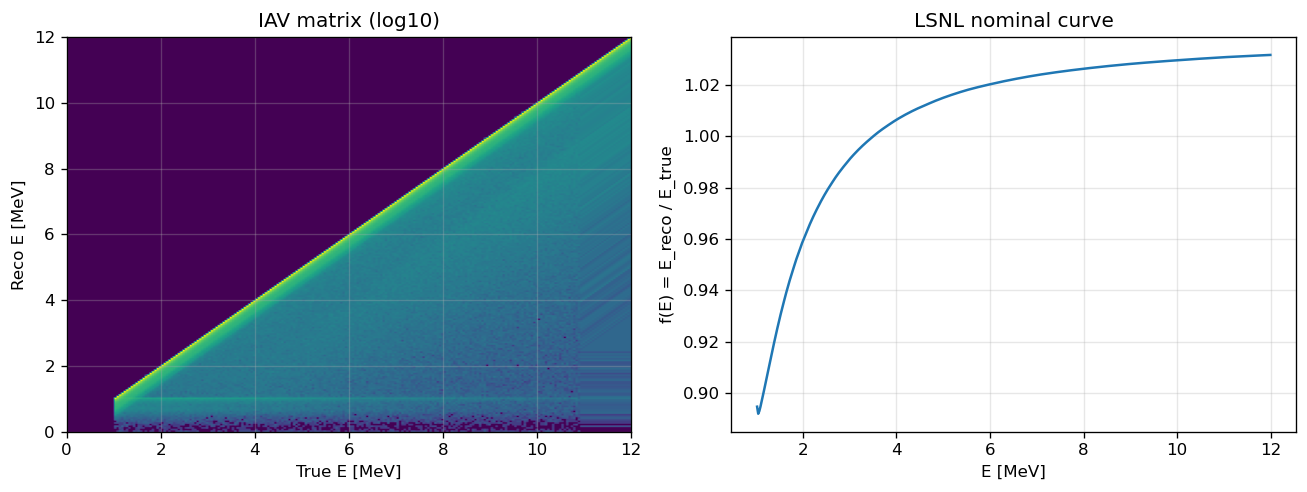

In [11]:
iav_bytes = fetch_bytes("detector_iav_matrix_iav_matrix.tsv.bz2")
iav_df = pd.read_csv(io.BytesIO(bz2.decompress(iav_bytes)), sep="\t", header=None)
assert iav_df.shape == (240, 240), f"expected a 240x240 IAV matrix, got {iav_df.shape}"
col_sums = iav_df.sum(axis=0)
print(f"IAV column-sum range: [{col_sums.min():.6f}, {col_sums.max():.6f}] (should be ~1)")

out = DATA_DIR / "iav_matrix.csv"
iav_df.to_csv(out, index=False, header=False)
print(f"wrote {out}  shape={iav_df.shape}")

lsnl_df = fetch_tsv_bz2("detector_lsnl_curves.tsv/detector_lsnl_curves_nominal.tsv.bz2")
out = DATA_DIR / "lsnl_curve_nominal.csv"
lsnl_df.to_csv(out, index=False)
print(f"wrote {out}  shape={lsnl_df.shape}")

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2))
axes[0].imshow(np.log10(iav_df.to_numpy().clip(min=1e-6)), origin="lower", extent=[0, 12, 0, 12], aspect="auto")
axes[0].set_xlabel("True E [MeV]"); axes[0].set_ylabel("Reco E [MeV]"); axes[0].set_title("IAV matrix (log10)")
axes[1].plot(lsnl_df["E_MeV"], lsnl_df["f"])
axes[1].set_xlabel("E [MeV]"); axes[1].set_ylabel("f(E) = E_reco / E_true"); axes[1].set_title("LSNL nominal curve")
plt.tight_layout(); plt.show()


## 14. Real Reactor Flux Corrections: Non-Equilibrium and SNF

Real relative corrections to the Huber-Mueller antineutrino spectrum: non-equilibrium (long-lived fission-daughter beta decays not yet in secular equilibrium, per isotope -- U235/Pu239/Pu241 only, no correction is published for U238) and spent nuclear fuel (SNF, residual antineutrino emission from stored used fuel assemblies, per reactor core R1-R6) -- `nonequilibrium_correction.tsv/*`, `snf_correction.tsv/*`. Both are additive fractional corrections to the nominal spectrum shape, `S_corrected(E) = S_nominal(E) * (1 + C(E))`.

**Expected results:**<br>
- The real reactor flux corrections: non-equilibrium and snf products are finite, dimensionally consistent, and reproducible from the cited primary source.
- Parsing, interpolation, normalization, and serialization preserve the published binning and physical measure.
- Validation diagnostics remain within the stated numerical and provenance tolerances.


wrote G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\detector\dayabay\nonequilibrium_correction.csv  shape=(810, 3)  isotopes=['U235', 'Pu239', 'Pu241'] (no correction published for U238)


wrote G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\detector\dayabay\snf_correction.csv  shape=(1206, 3)


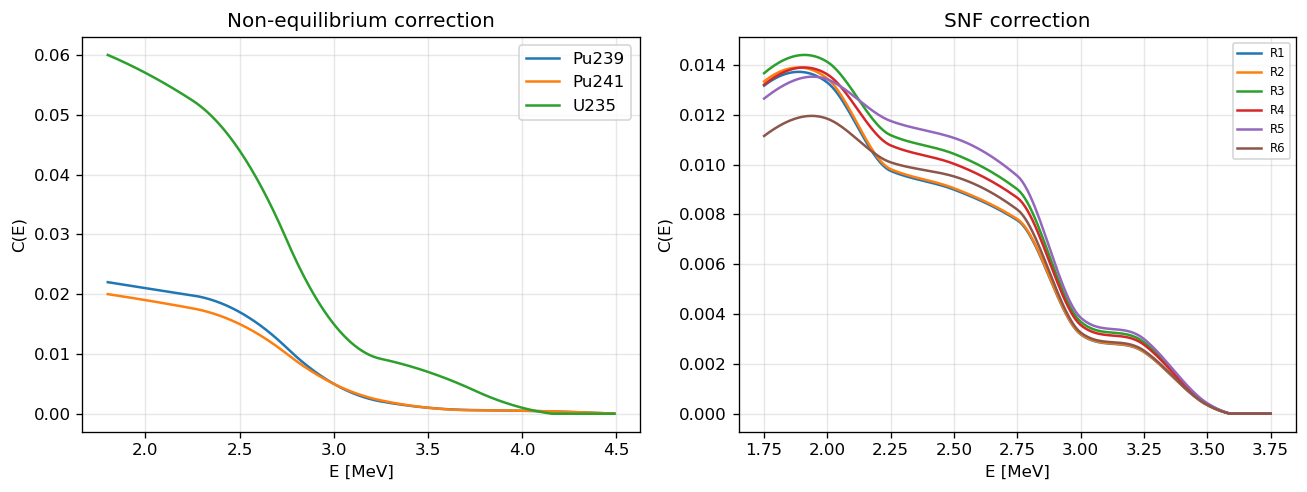

In [12]:
NEQ_ISOTOPES = ["U235", "Pu239", "Pu241"]
neq_frames = []
for iso in NEQ_ISOTOPES:
    df = fetch_tsv_bz2(f"nonequilibrium_correction.tsv/nonequilibrium_correction_{iso}.tsv.bz2")
    df.insert(0, "isotope", iso)
    neq_frames.append(df)
neq_df = pd.concat(neq_frames, ignore_index=True)
out = DATA_DIR / "nonequilibrium_correction.csv"
neq_df.to_csv(out, index=False)
print(f"wrote {out}  shape={neq_df.shape}  isotopes={NEQ_ISOTOPES} (no correction published for U238)")

snf_frames = []
for reactor in ["R1", "R2", "R3", "R4", "R5", "R6"]:
    df = fetch_tsv_bz2(f"snf_correction.tsv/snf_correction_{reactor}.tsv.bz2")
    df.insert(0, "reactor", reactor)
    snf_frames.append(df)
snf_df = pd.concat(snf_frames, ignore_index=True)
out = DATA_DIR / "snf_correction.csv"
snf_df.to_csv(out, index=False)
print(f"wrote {out}  shape={snf_df.shape}")

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2))
for iso, group in neq_df.groupby("isotope"):
    axes[0].plot(group["E_MeV"], group["C"], label=iso)
axes[0].set_xlabel("E [MeV]"); axes[0].set_ylabel("C(E)"); axes[0].set_title("Non-equilibrium correction"); axes[0].legend()
for reactor, group in snf_df.groupby("reactor"):
    axes[1].plot(group["E_MeV"], group["C"], label=reactor)
axes[1].set_xlabel("E [MeV]"); axes[1].set_ylabel("C(E)"); axes[1].set_title("SNF correction"); axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()


## 15. Real Weekly Reactor Antineutrino Rate

Real weekly-averaged per-reactor antineutrino emission rate (above the IBD threshold), spanning the full 2011-2020 data-taking period (6AD/8AD/7AD sub-periods, distinguishable via `n_det`/`n_det_mask`) -- `neutrino_rate.tsv/neutrino_rate_{R1..R6}.tsv.bz2`. Used to derive a real per-reactor *relative* power/output weight for the 8AD period (replacing the current implicit assumption that all 6 real cores contribute identically), while keeping the existing real thermal-power-based absolute flux normalization unchanged -- `tpeanuts.detector.dayabay.flux` for the exact usage.

**Expected results:**<br>
- The real weekly reactor antineutrino rate products are finite, dimensionally consistent, and reproducible from the cited primary source.
- Parsing, interpolation, normalization, and serialization preserve the published binning and physical measure.
- Validation diagnostics remain within the stated numerical and provenance tolerances.


wrote G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\detector\dayabay\neutrino_rate_weekly.csv  shape=(2814, 9)
real mean weekly antineutrino rate, 8AD period only (relative weights sum to ~6):


,relative_weight
reactor,
R1,1.001022
R2,0.990536
R3,1.012606
R4,0.996549
R5,1.007873
R6,0.991415


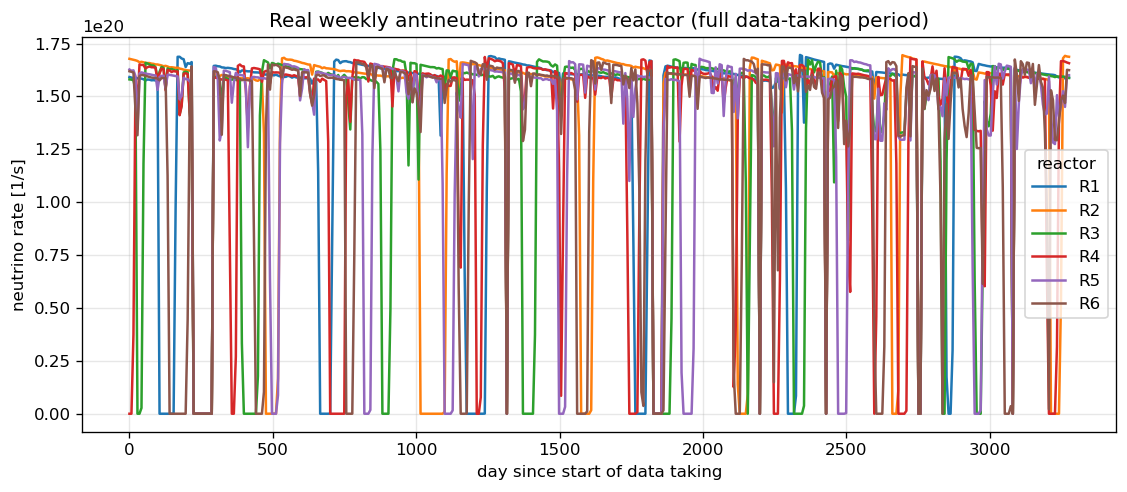

In [13]:
rate_frames = []
for reactor in ["R1", "R2", "R3", "R4", "R5", "R6"]:
    df = fetch_tsv_bz2(f"neutrino_rate.tsv/neutrino_rate_{reactor}.tsv.bz2")
    df.insert(0, "reactor", reactor)
    rate_frames.append(df)
rate_df = pd.concat(rate_frames, ignore_index=True)
out = DATA_DIR / "neutrino_rate_weekly.csv"
rate_df.to_csv(out, index=False)
print(f"wrote {out}  shape={rate_df.shape}")

rate_8ad = rate_df[rate_df["n_det"] == 8]
mean_rate_8ad = rate_8ad.groupby("reactor")["neutrino_rate_per_s"].mean()
print("real mean weekly antineutrino rate, 8AD period only (relative weights sum to ~6):")
display((mean_rate_8ad / mean_rate_8ad.mean()).rename("relative_weight").to_frame())

ax = rate_df.pivot(index="day", columns="reactor", values="neutrino_rate_per_s").plot(
    figsize=(9.5, 4.2), title="Real weekly antineutrino rate per reactor (full data-taking period)",
)
ax.set_xlabel("day since start of data taking"); ax.set_ylabel("neutrino rate [1/s]")
plt.tight_layout(); plt.show()


## 16. Real Global Normalization (Nominal)

Daya Bay's own official free-normalization nuisance parameter (`parameters/detector_normalization.yaml`), nominal value 1.0. The official analysis leaves this parameter free in its combined fit rather than fixing the absolute IBD rate prediction to Daya Bay's own target/efficiency/flux normalization chain -- this project's fits follow the same real, published convention (see `tpeanuts.detector.dayabay.inference_model`).

**Expected results:**<br>
- The real global normalization (nominal) products are finite, dimensionally consistent, and reproducible from the cited primary source.
- Parsing, interpolation, normalization, and serialization preserve the published binning and physical measure.
- Validation diagnostics remain within the stated numerical and provenance tolerances.


In [14]:
global_normalization = fetch_yaml("parameters/detector_normalization.yaml")["parameters"]["global_normalization"]
out = DATA_DIR / "global_normalization.txt"
with open(out, "w") as f:
    f.write(str(global_normalization))
print(f"wrote {out}: nominal global_normalization = {global_normalization}")


wrote G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\detector\dayabay\global_normalization.txt: nominal global_normalization = 1.0


## 18. Real LSNL Pull Curves (Systematic Variations)

The 4 real LSNL systematic-variation curves (`pull0`-`pull3`) that, combined with the nominal curve (Section 12) via the official linear model `f(E) = f0(E) + sum_k a_k*(f_k(E)-f0(E))` (`parameters/detector_lsnl.yaml`, each `a_k` a real free nuisance with a unit Gaussian prior), let a fit vary the LSNL energy-scale curve within its real systematic uncertainty band -- `detector_lsnl_curves.tsv/detector_lsnl_curves_pull{0..3}.tsv.bz2`.

**Expected results:**<br>
- The real lsnl pull curves (systematic variations) products are finite, dimensionally consistent, and reproducible from the cited primary source.
- Parsing, interpolation, normalization, and serialization preserve the published binning and physical measure.
- Validation diagnostics remain within the stated numerical and provenance tolerances.


wrote G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\detector\dayabay\lsnl_curve_pulls.csv  shape=(1832, 3)


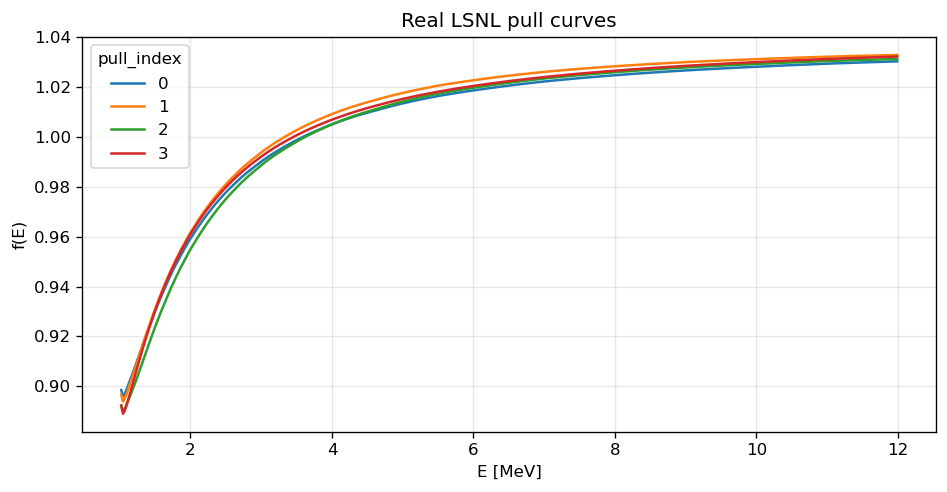

In [15]:
lsnl_pull_frames = []
for k in range(4):
    df = fetch_tsv_bz2(f"detector_lsnl_curves.tsv/detector_lsnl_curves_pull{k}.tsv.bz2")
    df.insert(0, "pull_index", k)
    lsnl_pull_frames.append(df)
lsnl_pull_df = pd.concat(lsnl_pull_frames, ignore_index=True)
out = DATA_DIR / "lsnl_curve_pulls.csv"
lsnl_pull_df.to_csv(out, index=False)
print(f"wrote {out}  shape={lsnl_pull_df.shape}")

ax = lsnl_pull_df.pivot(index="E_MeV", columns="pull_index", values="f").plot(
    figsize=(8.0, 4.2), title="Real LSNL pull curves",
)
ax.set_xlabel("E [MeV]"); ax.set_ylabel("f(E)")
plt.tight_layout(); plt.show()


## 19. Summary
---
Wrote real Daya Bay Collaboration data to `data/detector/dayabay/`: `baselines.csv` (6x8 geometry), `reactor_parameters.csv`/`reactor_thermal_power_gw.txt`, `huber_mueller_spectra.csv` (4 isotopes), `n_protons.csv`, `eres_parameters.csv`, `detector_efficiency.txt` (real IBD-selection efficiency, separate from the daily eff_livetime), `ibd_spectra/*.csv` (8 real observed spectra), `background_rates_8AD.csv` + `background_shapes/*.csv` (real backgrounds), `exposure_8AD.csv` (real livetime), `final_erec_bin_edges.csv` (real analysis binning), `survival_probability_truth.csv` (Daya Bay's own published best fit, for comparison only), `ibd_constants.csv`, `iav_matrix.csv`, `lsnl_curve_nominal.csv`, `nonequilibrium_correction.csv`, `snf_correction.csv`, `neutrino_rate_weekly.csv`, `global_normalization.txt`, and `lsnl_curve_pulls.csv`.

`tpeanuts.detector.dayabay` consumes these directly, including the real IBD cross-section constants, IAV response matrix, LSNL curve, non-equilibrium/SNF flux corrections, and weekly reactor-rate history added above. See that package's module docstring for the remaining simplifications relative to the official analysis (full systematic covariance/pull curves, and the 6AD/7AD periods).

**Expected results:**<br>
- The summary products are finite, dimensionally consistent, and reproducible from the cited primary source.
- Parsing, interpolation, normalization, and serialization preserve the published binning and physical measure.
- Validation diagnostics remain within the stated numerical and provenance tolerances.
